## Holiday Package Prediciton

### 1) Problem statement.
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base.
One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information.
The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being.
However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.
### 2) Data Collection.
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction
The data consists of 20 column and 4888 rows.

In [3]:
## importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

In [5]:
df=pd.read_csv(r"C:\Users\ASUS\OneDrive\Videos\ML Model Implementations\11_Random_Forest\Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


# Columns Information

| 🔢 No. | Column Name              | Description                         | Type                   | Values / Notes                                        |
| ------ | ------------------------ | ----------------------------------- | ---------------------- | ----------------------------------------------------- |
| 1      | CustomerID               | Unique identifier for each customer | Integer                | Not useful for model (drop)                           |
| 2      | ProdTaken 🎯             | Target variable (purchase or not)   | Binary                 | 1 = Yes, 0 = No                                       |
| 3      | Age                      | Age of customer                     | Numerical (Continuous) | —                                                     |
| 4      | TypeofContact            | Mode of contact                     | Categorical            | Company Invited, Self Inquiry                         |
| 5      | CityTier                 | City category                       | Ordinal                | 1 = Metro, 2 = Tier-2, 3 = Tier-3                     |
| 6      | DurationOfPitch          | Duration of sales pitch (minutes)   | Numerical              | —                                                     |
| 7      | Occupation               | Customer occupation                 | Categorical            | Salaried, Small Business, Large Business, Free Lancer |
| 8      | Gender                   | Gender of customer                  | Categorical            | Male, Female                                          |
| 9      | NumberOfPersonVisiting   | Total people traveling              | Numerical (Discrete)   | —                                                     |
| 10     | NumberOfFollowups        | Follow-up calls count               | Numerical (Discrete)   | —                                                     |
| 11     | ProductPitched           | Type of product offered             | Categorical            | Basic, Standard, Deluxe, Super Deluxe, King           |
| 12     | PreferredPropertyStar    | Preferred hotel rating              | Ordinal                | 1 to 5                                                |
| 13     | MaritalStatus            | Marital status                      | Categorical            | Married, Single, Divorced                             |
| 14     | NumberOfTrips            | Trips per year                      | Numerical              | —                                                     |
| 15     | Passport                 | Has passport or not                 | Binary                 | 1 = Yes, 0 = No                                       |
| 16     | PitchSatisfactionScore   | Satisfaction after pitch            | Ordinal                | 1 to 5                                                |
| 17     | OwnCar                   | Owns a car or not                   | Binary                 | 1 = Yes, 0 = No                                       |
| 18     | NumberOfChildrenVisiting | Children traveling                  | Numerical              | —                                                     |
| 19     | Designation              | Job level                           | Ordinal                | Executive → VP                                        |
| 20     | MonthlyIncome            | Monthly income                      | Numerical              | Strong feature                                        |


In [6]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Data Cleaning
### Handling Missing values
1. Handling Missing values
2. Handling Duplicates
3. Check data type
4. Understand the dataset

In [8]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [14]:
df['Gender']=df['Gender'].replace("Fe Male", "Female")

In [15]:
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [ ]:
df['Gender'].value_counts()

In [17]:
categorical_cols = [
    'TypeofContact',
    'Occupation',
    'Gender',
    'ProductPitched',
    'MaritalStatus',
    'Designation'
]

binary_cols = [
    'Passport',
    'OwnCar',
    'ProdTaken'
]

discrete_cols = [
    'CityTier',
    'NumberOfFollowups',
    'PreferredPropertyStar',
    'PitchSatisfactionScore'
]

for col in categorical_cols + binary_cols + discrete_cols:
    print(f"\n-> {col} Value Counts:\n")
    print(df[col].value_counts())


-> TypeofContact Value Counts:

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

-> Occupation Value Counts:

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

-> Gender Value Counts:

Gender
Male      2916
Female    1972
Name: count, dtype: int64

-> ProductPitched Value Counts:

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

-> MaritalStatus Value Counts:

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

-> Designation Value Counts:

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64

-> Passport Value Counts:

Passport
0    3466
1    1422
Name: count, dtype: int64

-> OwnCar Value Counts:

OwnCar
1    3

In [22]:
df['MaritalStatus']=df['MaritalStatus'].replace('Single', 'Unmarried')

In [23]:
df['MaritalStatus'].unique()

<StringArray>
['Unmarried', 'Divorced', 'Married']
Length: 3, dtype: str

In [18]:
numerical_cols = [
    'Age',
    'DurationOfPitch',
    'NumberOfTrips',
    'MonthlyIncome',
    'NumberOfPersonVisiting',
    'NumberOfChildrenVisiting'
]

df[numerical_cols].describe()

,Age,DurationOfPitch,NumberOfTrips,MonthlyIncome,NumberOfPersonVisiting,NumberOfChildrenVisiting
count,4662.000000,4637.000000,4748.000000,4655.000000,4888.000000,4822.000000
mean,37.622265,15.490835,3.236521,23619.853491,2.905074,1.187267
std,9.316387,8.519643,1.849019,5380.698361,0.724891,0.857861
min,18.000000,5.000000,1.000000,1000.000000,1.000000,0.000000
25%,31.000000,9.000000,2.000000,20346.000000,2.000000,1.000000
50%,36.000000,13.000000,3.000000,22347.000000,3.000000,1.000000
75%,44.000000,20.000000,4.000000,25571.000000,3.000000,2.000000
max,61.000000,127.000000,22.000000,98678.000000,5.000000,3.000000


In [19]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

## Filling Missing Values

In [24]:
# For age
df["Age"]=df["Age"].fillna(df['Age'].mean(), inplace=True)

In [25]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                           0
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [ ]:
df['TypeofContact'].mode()[0]

'Self Enquiry'

In [35]:
df['TypeofContact']=df['TypeofContact'].fillna(df['TypeofContact'].mode()[0], inplace=True)

In [47]:
df['NumberOfFollowups']=df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].median(), inplace=True)

In [51]:
df['NumberOfTrips']=df['NumberOfTrips'].fillna(df['NumberOfTrips'].median(), inplace=True)

In [53]:
df['NumberOfChildrenVisiting']=df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].median(), inplace=True)

In [55]:
df['MonthlyIncome']=df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)

In [49]:
df['PreferredPropertyStar']=df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].median(), inplace=True)

In [43]:
df['DurationOfPitch']=df['DurationOfPitch'].fillna(df['DurationOfPitch'].median(), inplace=True)

In [58]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [57]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='str')

In [60]:
df.drop('CustomerID', inplace=True, axis=1)

In [65]:
df.dtypes

ProdTaken                     int64
Age                         float64
TypeofContact                   str
CityTier                      int64
DurationOfPitch             float64
Occupation                      str
Gender                          str
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched                  str
PreferredPropertyStar       float64
MaritalStatus                   str
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                     str
MonthlyIncome               float64
dtype: object

# Feature Engineering 

In [66]:
## get all the numeric features
num_features = [feature for feature in df.columns if df[feature].dtype != 'str']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 13


In [ ]:
## categorical features
cat_features = [feature for feature in df.columns if df[feature].dtype == "str"]
print('Num of Categorical Features :', len(cat_features))

Num of Categorical Features : 6


In [71]:
## Discrete features
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))

Num of Discrete Features : 10


In [72]:
## coontinuous features
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Continuous Features : 3


In [73]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.000000,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.000000,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.000000,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.000000,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,37.622265,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [74]:
X = df.drop('ProdTaken', axis=1)
y = df['ProdTaken']

In [79]:
categorical_cols = [
    'TypeofContact',
    'Occupation',
    'Gender',
    'ProductPitched',
    'MaritalStatus'
]

ordinal_cols = [
    'Designation',
    'CityTier',
    'PreferredPropertyStar'
]

numerical_cols = [
    col for col in X.columns if col not in categorical_cols + ordinal_cols
]

In [77]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((3910, 18), (978, 18))

In [78]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       4888 non-null   float64
 1   TypeofContact             4888 non-null   str    
 2   CityTier                  4888 non-null   int64  
 3   DurationOfPitch           4888 non-null   float64
 4   Occupation                4888 non-null   str    
 5   Gender                    4888 non-null   str    
 6   NumberOfPersonVisiting    4888 non-null   int64  
 7   NumberOfFollowups         4888 non-null   float64
 8   ProductPitched            4888 non-null   str    
 9   PreferredPropertyStar     4888 non-null   float64
 10  MaritalStatus             4888 non-null   str    
 11  NumberOfTrips             4888 non-null   float64
 12  Passport                  4888 non-null   int64  
 13  PitchSatisfactionScore    4888 non-null   int64  
 14  OwnCar             

### Encode Categorical 

In [97]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop="first", sparse_output=False)

In [106]:
X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])

X_train_cat

array([[1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 1., ..., 0., 1., 0.],
       [1., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.]], shape=(3910, 11))

In [ ]:
# Convert to DataFrame
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

X_train_cat_df = pd.DataFrame(X_train_cat, columns=cat_feature_names)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=cat_feature_names)

In [104]:
X_train_cat_df.head()

,TypeofContact_Self Enquiry,Occupation_Large Business,Occupation_Salaried,Occupation_Small Business,Gender_Male,ProductPitched_Deluxe,ProductPitched_King,ProductPitched_Standard,ProductPitched_Super Deluxe,MaritalStatus_Married,MaritalStatus_Unmarried
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Encode Ordinal

In [109]:
from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder()

X_train_ord = ord_encoder.fit_transform(X_train[ordinal_cols])
X_test_ord = ord_encoder.transform(X_test[ordinal_cols])

X_train_ord

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 2.],
       ...,
       [1., 2., 0.],
       [2., 2., 0.],
       [1., 0., 0.]], shape=(3910, 3))

In [111]:
# Convert to DataFrame
X_train_ord_df = pd.DataFrame(X_train_ord, columns=ordinal_cols)
X_test_ord_df = pd.DataFrame(X_test_ord, columns=ordinal_cols)

X_train_ord_df.head()

,Designation,CityTier,PreferredPropertyStar
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,2.0
3,2.0,0.0,0.0
4,1.0,0.0,0.0


In [112]:
designation_order = ["Executive", "Manager", "Senior Manager", "AVP", "VP"]

ord_encoder = OrdinalEncoder(categories=[
    designation_order,  # Designation
    [1, 2, 3],          # CityTier
    [1, 2, 3, 4, 5]     # PreferredPropertyStar
])

### Combine All Features

In [113]:
X_train_final = pd.concat([
    X_train[numerical_cols].reset_index(drop=True),
    X_train_ord_df.reset_index(drop=True),
    X_train_cat_df.reset_index(drop=True)
], axis=1)

X_test_final = pd.concat([
    X_test[numerical_cols].reset_index(drop=True),
    X_test_ord_df.reset_index(drop=True),
    X_test_cat_df.reset_index(drop=True)
], axis=1)

### Train the model

In [128]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train_final, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [129]:
df['ProdTaken'].value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [130]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9212678936605317

Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       787
           1       0.97      0.62      0.75       191

    accuracy                           0.92       978
   macro avg       0.94      0.81      0.85       978
weighted avg       0.92      0.92      0.91       978


Confusion Matrix: 
 [[783   4]
 [ 73 118]]


### Let us apply smote to improve data points for output 1 

In [117]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)

In [118]:
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_resampled).value_counts())

Before SMOTE:
 ProdTaken
0    3181
1     729
Name: count, dtype: int64

After SMOTE:
 ProdTaken
0    3181
1    3181
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model1 = RandomForestClassifier(n_estimators=100, random_state=42)

model1.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model1.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9079754601226994

Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.95       787
           1       0.95      0.56      0.70       191

    accuracy                           0.91       978
   macro avg       0.92      0.78      0.82       978
weighted avg       0.91      0.91      0.90       978


Confusion Matrix:
 [[781   6]
 [ 84 107]]


### Here, we trained model using smote but it is giving worse result then previous one 

## Now let us use class_weight="balanced" 

In [ ]:
model2 = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

model2.fit(X_train_final, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model2.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9100204498977505

Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.95       787
           1       0.96      0.57      0.71       191

    accuracy                           0.91       978
   macro avg       0.93      0.78      0.83       978
weighted avg       0.91      0.91      0.90       978


Confusion Matrix:
 [[782   5]
 [ 83 108]]


### It is giving good result then prev one (the smote one) but not better then default one

# Conclusion

### Default Model:
#### "The default Random Forest model performed well overall but struggled to correctly identify the minority class (class 1), leading to lower recall."

### Model with SMOTE:
#### "Applying SMOTE led to poorer performance, likely due to synthetic samples causing the model to overfit and reduce generalization."

### Model with class_weight='balanced':
#### "Using class_weight='balanced' improved the model’s ability to detect the minority class, resulting in better recall and more balanced performance."

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [131]:
y_prob = model.predict_proba(X_test_final)[:, 1]

In [133]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [134]:
auc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9761104865051857


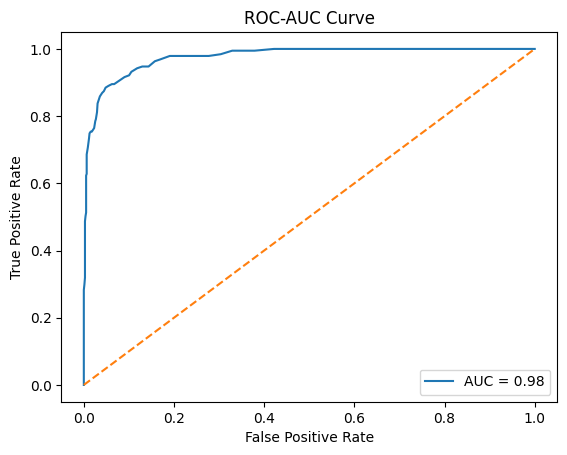

In [135]:
plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()

plt.show()

#### The model has strong discriminative power (high ROC-AUC), but the default classification threshold limits recall. Adjusting the threshold can significantly improve minority class detection